# Лабораторная работа №1: Первичное исследование данных

## 1. Постановка задачи

### Описание датасета
Датасет содержит сведения о произведениях искусства: название, техника, отдел музея, классификация, габариты объекта, а также даты создания и поступления в коллекцию. Отдельно хранятся данные об авторе: полное имя, национальность, годы жизни. Такой набор позволяет анализировать структуру музейной коллекции, времную динамику поступлений и особенности художников.

### Условный заказчик
Музей, кураторы выставок, аналитический отдел, команда онлайн‑каталога.

### Возможные задачи ИАД
1. Описательная аналитика по отделам, техникам, периодам поступления;
2. Поиск аномалий (подозрительные размеры, даты создания позже даты поступления и т.п.);
3. Профилирование художников по национальностям и периодам активности.

## 2. Паспорт датасета

### Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Загрузка данных
df = pd.read_csv('../date/cmoa.csv')  # Путь к вашему файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')


Размер датасета: 28269 строк, 29 столбцов


In [2]:
df.head()

,title,creation_date,creation_date_earliest,creation_date_latest,medium,accession_number,id,credit_line,date_acquired,department,...,artist_id,party_type,full_name,cited_name,role,nationality,birth_date,death_date,birth_place,death_place
0,Keith Haring,1984,1984-01-01,1984-01-01,gelatin silver print,2002.17,cmoa:things/692a68c5-af1e-4124-80f1-cbf38be51abe,Milton Fine Fund,2002-06-06,Contemporary Art,...,cmoa:parties/2cb30976-c292-4060-9dea-ba0e9504dda7,Person,Robert Mapplethorpe,"Mapplethorpe, Robert",NaN,American,1947-01-01,1989-01-01,"New York City (New York state, United States)","New York City (New York state, United States)"
1,Untitled,1964-1965,1964-01-01,1965-01-01,oil on canvas,2002.19,cmoa:things/871505af-a072-4a84-ab09-3abf932951b8,Joseph Soffer Family Trust Fund,2002-06-06,Contemporary Art,...,cmoa:parties/b5cb7ad2-50ca-4c5b-8a80-74202ddfb9c2,Person,Jo Baer,"Baer, Jo",NaN,American,1929-01-01,NaN,"Seattle (King County, Washington, United States)",NaN
2,Trans East West (Tew) No. 5: The Attack of the...,1999,1999-01-01,1999-01-01,mixed media on paper,2002.18.1,cmoa:things/fe93f7e2-e4ca-455e-bdfa-ea9be22cce8a,Second Century Acquisition Fund,2002-06-06,Contemporary Art,...,cmoa:parties/4c7afe88-ebfe-4e3b-9010-9ddcb1e11674,Person,Franz Ackermann,"Ackermann, Franz",NaN,German,1963-01-01,NaN,"Neumarkt-Sankt Veit (Oberbayern, Bavaria, Germ...",NaN
3,Trans East West (Tew) No. 6: Rebuilding Beyrut,1999,1999-01-01,1999-01-01,mixed media on paper,2002.18.2,cmoa:things/9ee75ef7-d8a6-47bc-a0fe-dda1ec7d2984,Second Century Acquisition Fund,2002-06-06,Contemporary Art,...,cmoa:parties/4c7afe88-ebfe-4e3b-9010-9ddcb1e11674,Person,Franz Ackermann,"Ackermann, Franz",NaN,German,1963-01-01,NaN,"Neumarkt-Sankt Veit (Oberbayern, Bavaria, Germ...",NaN
4,Trans East West (Tew) No. 7: Bombing the Power...,1999,1999-01-01,1999-01-01,mixed media on paper,2002.18.3,cmoa:things/d4e7057c-6f1f-4bce-be3e-579fe5ab2af6,Second Century Acquisition Fund,2002-06-06,Contemporary Art,...,cmoa:parties/4c7afe88-ebfe-4e3b-9010-9ddcb1e11674,Person,Franz Ackermann,"Ackermann, Franz",NaN,German,1963-01-01,NaN,"Neumarkt-Sankt Veit (Oberbayern, Bavaria, Germ...",NaN


### Структура данных

In [3]:
used_cols = [
    'title',
    'creation_date_earliest',
    'medium',
    'date_acquired',
    'department',
    'item_width',
    'item_height',
    'item_depth',
    'classification',
    'full_name',
    'nationality',
    'birth_date',
    'death_date'
]

df = df[used_cols].copy()
df.head()

,title,creation_date_earliest,medium,date_acquired,department,item_width,item_height,item_depth,classification,full_name,nationality,birth_date,death_date
0,Keith Haring,1984-01-01,gelatin silver print,2002-06-06,Contemporary Art,23.250,29.250,1.25,photographs,Robert Mapplethorpe,American,1947-01-01,1989-01-01
1,Untitled,1964-01-01,oil on canvas,2002-06-06,Contemporary Art,60.500,48.250,2.25,paintings,Jo Baer,American,1929-01-01,NaN
2,Trans East West (Tew) No. 5: The Attack of the...,1999-01-01,mixed media on paper,2002-06-06,Contemporary Art,7.500,5.125,0.00,drawings and watercolors,Franz Ackermann,German,1963-01-01,NaN
3,Trans East West (Tew) No. 6: Rebuilding Beyrut,1999-01-01,mixed media on paper,2002-06-06,Contemporary Art,7.438,5.125,0.00,drawings and watercolors,Franz Ackermann,German,1963-01-01,NaN
4,Trans East West (Tew) No. 7: Bombing the Power...,1999-01-01,mixed media on paper,2002-06-06,Contemporary Art,7.500,5.125,0.00,drawings and watercolors,Franz Ackermann,German,1963-01-01,NaN


В исходном датасете содержится 29 признаков, однако для данной лабораторной работы используются только 13, связанных с описанием произведения искусства, его автора и дат создания и поступления. Дальнейший анализ проводится по данному набору признаков.

In [4]:
# Информация о столбцах и типах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28269 entries, 0 to 28268
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   28154 non-null  str    
 1   creation_date_earliest  27912 non-null  str    
 2   medium                  28131 non-null  str    
 3   date_acquired           27852 non-null  str    
 4   department              28269 non-null  str    
 5   item_width              28269 non-null  float64
 6   item_height             28269 non-null  float64
 7   item_depth              28269 non-null  float64
 8   classification          28267 non-null  str    
 9   full_name               28251 non-null  str    
 10  nationality             28227 non-null  str    
 11  birth_date              22696 non-null  str    
 12  death_date              18383 non-null  str    
dtypes: float64(3), str(10)
memory usage: 2.8 MB


In [5]:
# Статистика по числовым признакам
df.describe()

,item_width,item_height,item_depth
count,28269.000000,28269.000000,28269.000000
mean,16.469858,16.580439,1.471958
std,21.146298,59.342263,6.405482
min,0.000000,0.000000,0.000000
25%,6.812000,7.250000,0.000000
50%,13.438000,13.500000,0.000000
75%,21.250000,21.000000,0.375000
max,1296.000000,9600.000000,426.000000


### Описание признаков

- `title` — название произведения искусства (картины, скульптуры и т.п.).
- `creation_date_earliest` — год или дата, когда работа была создана (самое раннее значение).
- `medium` — материал или техника (oil on canvas, bronze и т.п.).
- `date_acquired` — дата поступления объекта в коллекцию музея.
- `department` — отдел музея, которому принадлежит объект.
- `item_width` — ширина объекта (см/дюймы, зависит от источника данных).
- `item_height` — высота объекта.
- `item_depth` — глубина/толщина объекта.
- `classification` — тип объекта (Painting, Sculpture, Print и т.п.).
- `full_name` — полное имя автора.
- `nationality` — национальность автора.
- `birth_date` — год рождения автора.
- `death_date` — год смерти автора.


После начальной загрузки все признаки, кроме размеров, имели строковый тип.
Для удобства анализа были выполнены следующие преобразования типов:
- `creation_date_earliest`, `birth_date`, `death_date`, `date_acquired` приведён к типу datetime.

Остальные признаки (`title`, `medium`, `department`, `classification`, `full_name`, `nationality`) оставлены строковыми, так как используются как категориальные признаки.


In [6]:
# Приведение типов
def clean_date_column(series):
    dates = series.astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})', expand=False)
    return pd.to_datetime(dates, errors='coerce')

df['creation_date_earliest'] = clean_date_column(df['creation_date_earliest'])
df['birth_date'] = clean_date_column(df['birth_date'])
df['death_date'] = clean_date_column(df['death_date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28269 entries, 0 to 28268
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   title                   28154 non-null  str           
 1   creation_date_earliest  27912 non-null  datetime64[us]
 2   medium                  28131 non-null  str           
 3   date_acquired           27852 non-null  str           
 4   department              28269 non-null  str           
 5   item_width              28269 non-null  float64       
 6   item_height             28269 non-null  float64       
 7   item_depth              28269 non-null  float64       
 8   classification          28267 non-null  str           
 9   full_name               28251 non-null  str           
 10  nationality             28227 non-null  str           
 11  birth_date              22537 non-null  datetime64[us]
 12  death_date              17929 non-null  datetime64[us]
dt

In [7]:
df.head(103)

,title,creation_date_earliest,medium,date_acquired,department,item_width,item_height,item_depth,classification,full_name,nationality,birth_date,death_date
0,Keith Haring,1984-01-01,gelatin silver print,2002-06-06,Contemporary Art,23.250,29.250,1.250,photographs,Robert Mapplethorpe,American,1947-01-01,1989-01-01
1,Untitled,1964-01-01,oil on canvas,2002-06-06,Contemporary Art,60.500,48.250,2.250,paintings,Jo Baer,American,1929-01-01,NaT
2,Trans East West (Tew) No. 5: The Attack of the...,1999-01-01,mixed media on paper,2002-06-06,Contemporary Art,7.500,5.125,0.000,drawings and watercolors,Franz Ackermann,German,1963-01-01,NaT
3,Trans East West (Tew) No. 6: Rebuilding Beyrut,1999-01-01,mixed media on paper,2002-06-06,Contemporary Art,7.438,5.125,0.000,drawings and watercolors,Franz Ackermann,German,1963-01-01,NaT
4,Trans East West (Tew) No. 7: Bombing the Power...,1999-01-01,mixed media on paper,2002-06-06,Contemporary Art,7.500,5.125,0.000,drawings and watercolors,Franz Ackermann,German,1963-01-01,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Box,1820-01-01,mother of pearl,NaN,Decorative Arts and Design,3.000,1.250,2.375,containers,unknown Asian,Asian,NaT,NaT
99,Box,1820-01-01,mother of pearl,NaN,Decorative Arts and Design,3.000,1.250,2.375,containers,unknown Asian,Asian,NaT,NaT
100,Box,1820-01-01,mother of pearl,NaN,Decorative Arts and Design,2.750,1.250,5.125,containers,unknown Asian,Asian,NaT,NaT
101,Box,1820-01-01,mother of pearl,NaN,Decorative Arts and Design,3.000,1.375,2.375,containers,unknown Asian,Asian,NaT,NaT


## 3. Аудит качества данных

### 3.1. Пропуски

In [8]:
# Пропуски по столбцам
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

missing[missing['Пропуски'] > 0]

,Пропуски,Доля (%)
death_date,10340,36.58
birth_date,5732,20.28
date_acquired,417,1.48
creation_date_earliest,357,1.26
medium,138,0.49
title,115,0.41
nationality,42,0.15
full_name,18,0.06
classification,2,0.01


### 3.2. Дубликаты

In [9]:
# Находим дубликаты
duplicates_mask = df.duplicated(keep='first')
duplicates_df = df[duplicates_mask]

before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
removed = before - after

print(f"Всего дубликатов: {len(duplicates_df)}")
print(f"Было строк: {before}")
print(f"Стало строк: {after}")
print(f"Удалено дубликатов: {removed}")

Всего дубликатов: 2082
Было строк: 28269
Стало строк: 26187
Удалено дубликатов: 2082


In [10]:
key_dups = df.duplicated(subset=['title', 'full_name', 'creation_date_earliest']).sum() #название, имя автора, дата создания
print(f'Дубликатов по ключу (title, full_name, creation_date_earliest): {key_dups}')

Дубликатов по ключу (title, full_name, creation_date_earliest): 2956


Отдельно проверели потенциальные дубликаты по сочетанию `title`, `full_name`, `creation_date_earliest` как приближённому идентификатору произведения.
Количество дубликатов по этому ключу составило 2956 записей.

### 3.3. Типические проблемы значений
### 3.3.1. Числовые признаки

In [11]:
# Базовая статистика по числовым признакам
numeric_cols = ['item_width', 'item_height', 'item_depth']
for col in numeric_cols:
    print(f'\nСтолбец: {col}')
    print('Минимум:', df[col].min())
    print('Максимум:', df[col].max())
    print('Количество нулевых значений:', (df[col] == 0).sum())
    print('Количество отрицательных значений:', (df[col] < 0).sum())


Столбец: item_width
Минимум: 0.0
Максимум: 1296.0
Количество нулевых значений: 1674
Количество отрицательных значений: 0

Столбец: item_height
Минимум: 0.0
Максимум: 9600.0
Количество нулевых значений: 921
Количество отрицательных значений: 0

Столбец: item_depth
Минимум: 0.0
Максимум: 426.0
Количество нулевых значений: 19195
Количество отрицательных значений: 0


Для числовых признаков `item_width`, `item_height`, `item_depth` рассмотрены минимум, максимум, среднее и стандартное отклонение.
В данных присутствуют значения, близкие к нулю, что может означать либо отсутствующие измерения, либо ошибочный ввод. Отрицательных значений не обнаружено.

### 3.3.2. Категориальные признаки

In [12]:
cat_cols = ['department', 'classification', 'medium', 'nationality']

# Количество уникальных значений по категориальным признакам
for col in cat_cols:
    print(f'\nСтолбец: {col}')
    print('Уникальных значений:', df[col].nunique())
for col in cat_cols:
    print(f'\nПримеры категорий в столбце {col}:')
    print(df[col].dropna().unique()[:20])

df['medium_clean'] = df['medium'].str.lower().str.strip()
df['medium_clean'] = df['medium_clean'].str.replace(r'\s+', ' ', regex=True)
df['medium_clean'] = df['medium_clean'].str.replace(r'[^\w\s]', '', regex=True)

print('\nmedium:')
print(f'До: {df["medium"].nunique()}')
print(f'После: {df["medium_clean"].nunique()}')

def clean_nationality(value):
    if pd.isna(value):
        return value
    parts = [p.strip() for p in str(value).split('|') if p.strip()]
    if len(set(parts)) == 1:
        return parts[0]
    else:
        return '|'.join(parts)

df['nationality_clean'] = df['nationality'].apply(clean_nationality)

print('\nnationality:')
print(f'До: {df["nationality"].nunique()}')
print(f'После: {df["nationality_clean"].nunique()}')

print('\nПримеры изменений nationality:')
comparison = pd.DataFrame({
    'до': df['nationality'].head(20),
    'после': df['nationality_clean'].head(20)
})
print(comparison)

'classification'
df['classification_clean'] = df['classification'].str.lower().str.strip()
df['classification_clean'] = df['classification_clean'].str.replace(r'\s+', ' ', regex=True)
df['classification_clean'] = df['classification_clean'].str.replace(r'[^\w\s]', '', regex=True)

print('\nclassification:')
print(f'До: {df["classification"].nunique()}')
print(f'После: {df["classification_clean"].nunique()}')


Столбец: department
Уникальных значений: 6

Столбец: classification
Уникальных значений: 42

Столбец: medium
Уникальных значений: 5001

Столбец: nationality
Уникальных значений: 345

Примеры категорий в столбце department:
<StringArray>
[          'Contemporary Art', 'Decorative Arts and Design',
                'Photography',                  'Fine Arts',
 'Heinz Architectural Center',             'Film and Video']
Length: 6, dtype: str

Примеры категорий в столбце classification:
<StringArray>
[             'photographs',                'paintings',
 'drawings and watercolors',                    'Glass',
         'lighting devices',                   'Metals',
                 'Ceramics',                     'Wood',
                   'prints',               'containers',
                'sculpture',                'furniture',
                 'collages',            'installations',
     'architectural models',   'weapons and ammunition',
                    'books',      'tools a

### 3.4. Выбросы (пример для одного признака)

In [13]:
column = 'item_height'

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}')

Выбросов по методу IQR: 1167


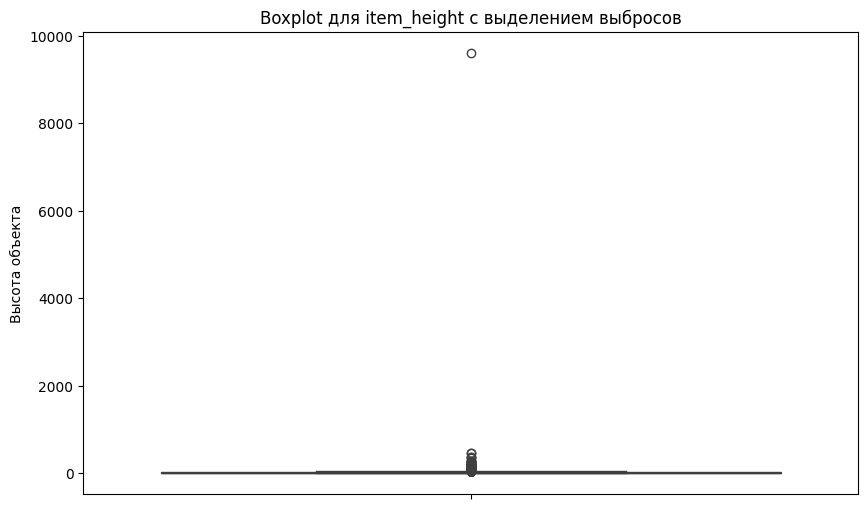

In [14]:
# Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y=column)
plt.title(f'Boxplot для {column} с выделением выбросов')
plt.ylabel('Высота объекта')
plt.show()

In [15]:
top_outliers = df.nlargest(10, 'item_height')[['title', 'item_height', 'item_depth', 'item_width', 'classification']]
print(top_outliers)

                                                   title  item_height  \
11481                                           Untitled      9600.00   
20213                                           Carnegie       466.00   
12755                                      Forbes Avenue       451.25   
22916              Procession of a Delegation from Korea       364.50   
19369                              Pittsburgh Variations       360.00   
20357  Wall Drawing #450, A wall is divided verticall...       354.00   
9988               Alexander Entering Babylon in Triumph       288.00   
17041                                  Two Slender Lines       279.00   
25950                                           Untitled       277.50   
1399                                 Untitled (Domestic)       266.00   

       item_depth  item_width            classification  
11481         7.0       13.50                 sculpture  
20213       255.0      228.00                 sculpture  
12755         0.0     

In [16]:
df_clean = df[df['item_height'] <= 200]

print(f"Было строк: {len(df)}")
print(f"Стало строк: {len(df_clean)}")
print(f"Удалено строк: {len(df) - len(df_clean)}")

Было строк: 26187
Стало строк: 26171
Удалено строк: 16


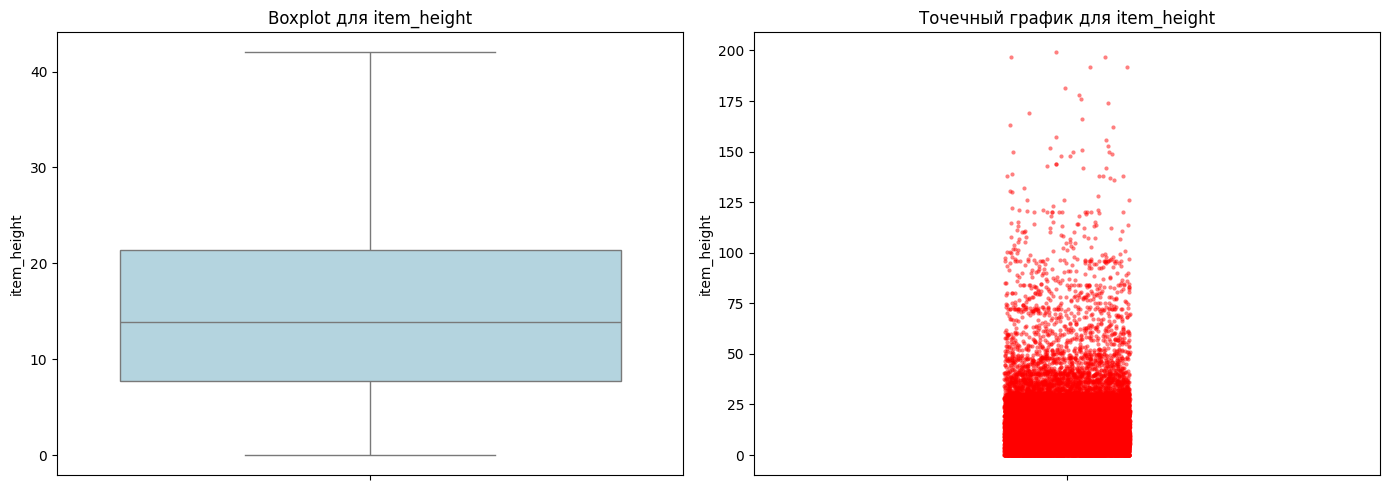

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, y=column, showfliers=False, color='lightblue')
plt.title(f'Boxplot для {column}')
plt.ylabel(column)

plt.subplot(1, 2, 2)
sns.stripplot(data=df_clean, y=column, color='red', alpha=0.5, size=3, jitter=True)
plt.title(f'Точечный график для {column}')
plt.ylabel(column)

plt.tight_layout()
plt.show()

## 4. Разведочный анализ (EDA)

### 4.1. Распределение числового признака

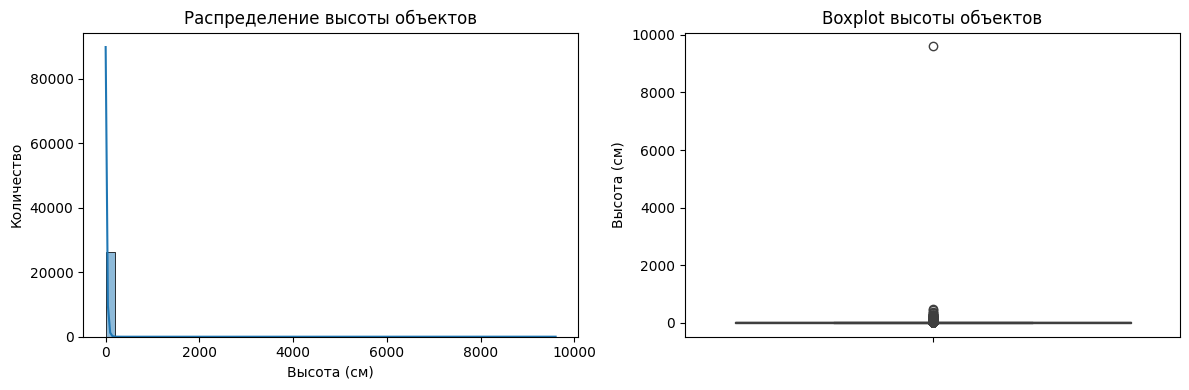

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['item_height'], bins=50, kde=True)
plt.title('Распределение высоты объектов')
plt.xlabel('Высота (см)')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['item_height'])
plt.title('Boxplot высоты объектов')
plt.ylabel('Высота (см)')

plt.tight_layout()
plt.show()

Видно, что большинство объектов имеют высоту до 100 см, но есть несколько экстремально высоких значений (до 9600 см). Это могут быть либо архитектурные объекты, либо ошибки в данных. Возможно, стоит рассмотреть отдельно "нормальные" объекты и архитектурные элементы.

### Распределение категориального признака

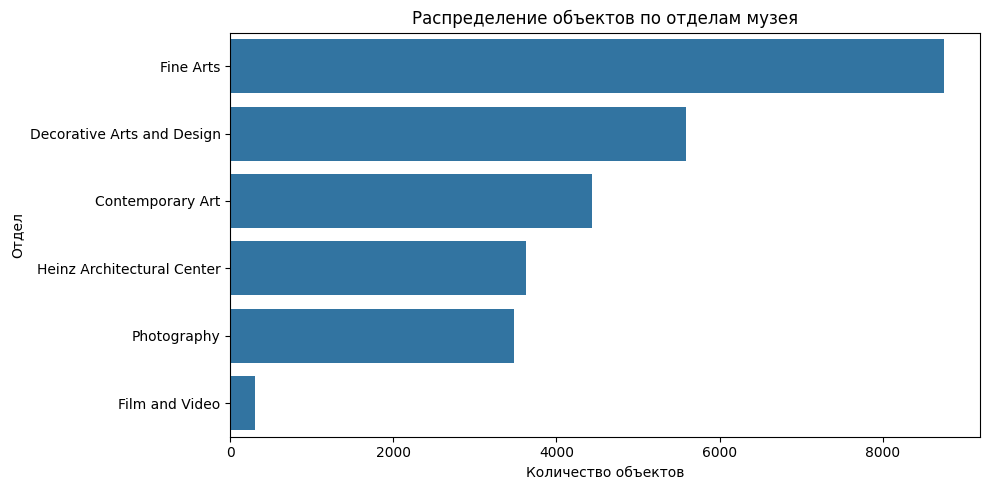

In [19]:
plt.figure(figsize=(10, 5))
dept_counts = df['department'].value_counts()
sns.barplot(x=dept_counts.values, y=dept_counts.index)
plt.title('Распределение объектов по отделам музея')
plt.xlabel('Количество объектов')
plt.ylabel('Отдел')
plt.tight_layout()
plt.show()

Гистограмма по столбцу `department` показывает, что несколько отделов содержат основную часть коллекции, тогда как остальные представлены значительно меньше.
Это может означать специализацию музея на определённых типах произведений или исторических периодах.
Возникает вопрос, связано ли такое распределение с политикой комплектования или с неполнотой данных по отдельным отделам.

### 4.2. Зависимость между двумя признаками

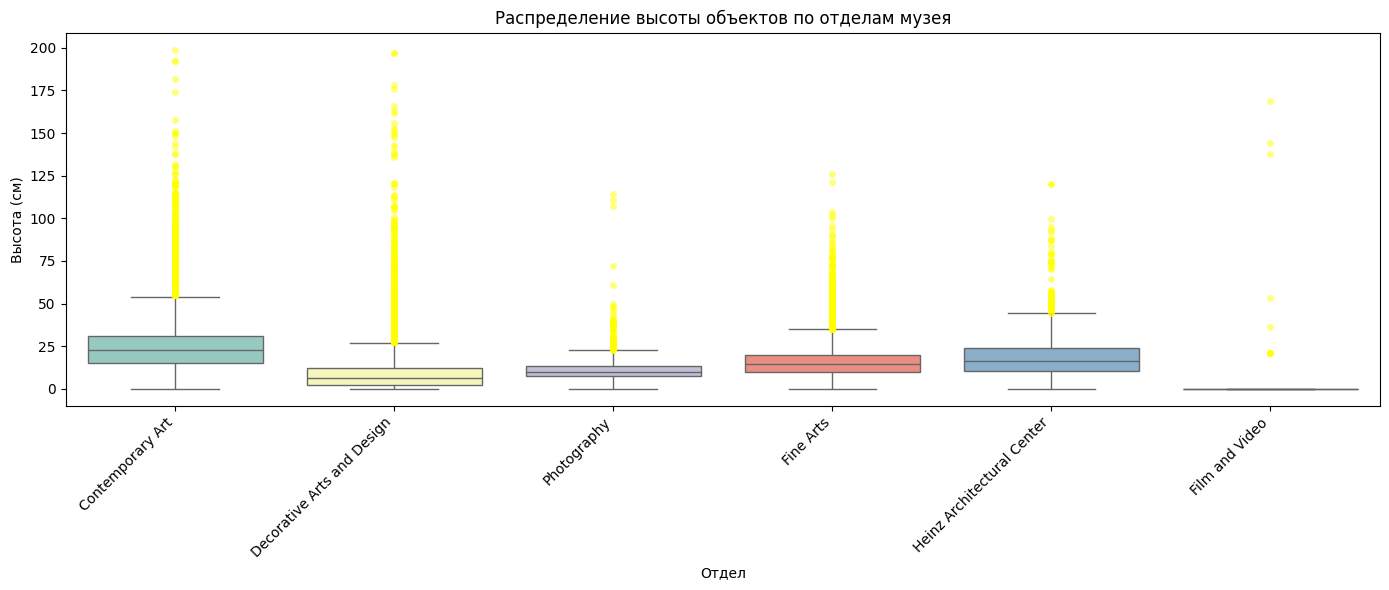

In [20]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df_clean, x='department', y='item_height', hue='department',
            palette="Set3",
            showfliers=True,
            flierprops=dict(marker='o', markerfacecolor='yellow', markeredgewidth=0, markersize=5, alpha=0.5))
plt.title('Распределение высоты объектов по отделам музея')
plt.xlabel('Отдел')
plt.ylabel('Высота (см)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

В отделе "Fine Arts" наблюдается наибольший разброс высот и самые высокие объекты. "Photography" и "Film and Video" имеют компактные размеры - вероятно, это стандартные форматы. Медианная высота во всех отделах примерно одинакова (около 20-30 см), кроме "Heinz Architectural Center".

## 5. Выводы

Детали в файле `report/quality_report.md`